# Klasteryzacja/Kategoryzacja supervised datasetu FMA small (8000 utworow 30 sekundowych)

## Przygotowanie danych

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, silhouette_score, adjusted_rand_score
import warnings
import os
import data_operations as do
import representations as rep
from tqdm import tqdm

In [22]:
print("Wczytywanie metadanych...")
tracks = pd.read_csv('fma_metadata/tracks.csv',skiprows=3,header=None)# kolumna 40 - genres_top , kolumna 32 - subsets

tracks = tracks[[0, 32, 40]].copy()

tracks.columns = ['track_id', 'subset', 'genre']

tracks_small = tracks[tracks['subset']=='small'].reset_index(drop=True)

print(len(tracks_small))
print(tracks_small.head())


X_features = []  
y_labels = []   
valid_ids = []

print("Rozpoczynam ekstrakcję cech")

for _, row in tqdm(tracks_small.iterrows(), total=tracks_small.shape[0]):
    
    track_id = row['track_id']
    genre = row['genre']
    

    tid_str = '{:06d}'.format(int(track_id))
    folder_name = tid_str[:3]
    file_name = tid_str + '.mp3'
    file_path = os.path.join("fma_small", folder_name, file_name)
    
    if not os.path.exists(file_path):
        continue
        
    try:
        audio_array = do.load_audio(file_path)
        feats = rep.song_to_representation(audio_array)
    
        X_features.append(feats)
        y_labels.append(genre)
        valid_ids.append(track_id)
        
    except Exception as e:

        print(f"Błąd przy pliku {file_path}: {e}")
        continue

X = np.array(X_features)
y = np.array(y_labels)

print(f"\nSukces! Przetworzono {len(X)} utworów.")
print(f"Kształt macierzy X: {X.shape}")
print(f"Kształt wektora y: {y.shape}")

np.save('X_data.npy', X)
np.save('y_data.npy', y)

print("Dane zapisane do plików 'X_data.npy' i 'y_data.npy'.")

Wczytywanie metadanych...
8000
   track_id subset    genre
0         2  small  Hip-Hop
1         5  small  Hip-Hop
2        10  small      Pop
3       140  small     Folk
4       141  small     Folk
Rozpoczynam ekstrakcję cech


 55%|█████▌    | 4426/8000 [09:38<04:39, 12.81it/s]

Błąd przy pliku fma_small/098/098565.mp3: axis 1 is out of bounds for array of dimension 1
Błąd przy pliku fma_small/098/098567.mp3: axis 1 is out of bounds for array of dimension 1
Błąd przy pliku fma_small/098/098569.mp3: axis 1 is out of bounds for array of dimension 1


 56%|█████▌    | 4472/8000 [09:44<06:18,  9.33it/s]

Błąd przy pliku fma_small/099/099134.mp3: index 0 is out of bounds for axis 0 with size 0


...

Błąd przy pliku fma_small/108/108925.mp3: index 0 is out of bounds for axis 0 with size 0


 87%|████████▋ | 6967/8000 [15:11<01:55,  8.97it/s]

Błąd przy pliku fma_small/133/133297.mp3: index 0 is out of bounds for axis 0 with size 0


100%|██████████| 8000/8000 [17:30<00:00,  7.62it/s]


Sukces! Przetworzono 7994 utworów.
Kształt macierzy X: (7994, 123)
Kształt wektora y: (7994,)
Dane zapisane do plików 'X_data.npy' i 'y_data.npy'.


## Wizualizacja reprezentacji w 3d

In [51]:
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd
from sklearn.preprocessing import StandardScaler

def visualise_3d (X,y):

    scaler_vis = StandardScaler()
    X_scaled_vis = scaler_vis.fit_transform(X)

    tsne = TSNE(n_components=3, random_state=42, n_jobs=-1) 
    X_embedded = tsne.fit_transform(X_scaled_vis)


    df_tsne = pd.DataFrame(X_embedded, columns=['x', 'y', 'z'])
    df_tsne['Genre'] = y


    fig = px.scatter_3d(
        df_tsne, 
        x='x', y='y', z='z',
        color='Genre',
        title='Wizualizacja 3D zbioru danych FMA',
        opacity=0.7,
        width=1000,
        height=800
    )

    fig.update_traces(marker=dict(size=3))
    fig.show()
visualise_3d(X,y)

In [47]:
import librosa
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

def extract_features_librosa(file_path):
    try:
        y, sr = librosa.load(file_path)

        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        zcr_var = np.std(zcr)

        cent = librosa.feature.spectral_centroid(y=y, sr=sr)
        cent_mean = np.mean(cent)
        cent_var = np.std(cent)
        

        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        rolloff_mean = np.mean(rolloff)
        rolloff_var = np.std(rolloff)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_var = np.std(mfcc, axis=1)
        

        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_var = np.std(chroma, axis=1)

        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        flatness = librosa.feature.spectral_flatness(y=y)
        flatness_mean = np.mean(flatness)
        flatness_var = np.std(flatness)

        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        bandwidth_mean = np.mean(bandwidth)
        bandwidth_var = np.std(bandwidth)

        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)
        contrast_var = np.std(contrast, axis=1)
        

        features = np.hstack([
            zcr_mean, zcr_var, 
            cent_mean, cent_var, 
            rolloff_mean, rolloff_var, 
            mfcc_mean, mfcc_var,
            chroma_mean, chroma_var,
            tempo,
            flatness_mean, flatness_var,
            bandwidth_mean, bandwidth_var,
            contrast_mean, contrast_var
        ])
        
        return features
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

if 'tracks_small' not in locals():
    print("Ładowanie metadanych (tracks_small) dla potrzeb pętli...")
    tracks = pd.read_csv('fma_metadata/tracks.csv', skiprows=3, header=None)
    tracks = tracks[[0, 32, 40]].copy()
    tracks.columns = ['track_id', 'subset', 'genre']
    tracks_small = tracks[tracks['subset']=='small'].reset_index(drop=True)

print("Rozpoczynam ekstrakcję cech przy użyciu biblioteki LIBROSA (Rozszerzona)...")

X_librosa_list = []
y_librosa_list = []

for _, row in tqdm(tracks_small.iterrows(), total=tracks_small.shape[0]):
    track_id = row['track_id']
    genre = row['genre']
    
    tid_str = '{:06d}'.format(int(track_id))
    folder_name = tid_str[:3]
    file_name = tid_str + '.mp3'
    file_path = os.path.join("fma_small", folder_name, file_name)
    
    if not os.path.exists(file_path):
        continue
        
    feat = extract_features_librosa(file_path)
    if feat is not None:
        X_librosa_list.append(feat)
        y_librosa_list.append(genre)

X_librosa = np.array(X_librosa_list)
y_librosa = np.array(y_librosa_list)

print(f"\nEkstrakcja zakończona sukcesem.")
print(f"Nowy kształt macierzy X: {X_librosa.shape}")
print(f"Nowy kształt wektora y: {y_librosa.shape}")

np.save('X_data_librosa.npy', X_librosa)
np.save('y_data_librosa.npy', y_librosa)

Rozpoczynam ekstrakcję cech przy użyciu biblioteki LIBROSA (Rozszerzona)...


  6%|▌         | 490/8000 [01:33<22:53,  5.47it/s] [src/libmpg123/layer3.c:INT123_do_layer3():1948] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1948] error: dequantization failed!
 11%|█▏        | 901/8000 [02:47<21:25,  5.52it/s][src/libmpg123/layer3.c:INT123_do_layer3():1908] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1908] error: dequantization failed!
 20%|██        | 1622/8000 [05:00<19:28,  5.46it/s]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
 55%|█████▌    | 4423/8000 [13:35<10:49,  5.51it/s]Note: Illegal Audio-MPEG-Header 0x00000000 at offset 33361.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1389] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).
/var/folders/46/8b8szllj315576515

Error processing fma_small/099/099134.mp3: 


 59%|█████▉    | 4721/8000 [14:28<09:56,  5.50it/s]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
 59%|█████▉    | 4722/8000 [14:28<09:39,  5.65it/s]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
 61%|██████▏   | 4903/8000 [15:01<09:25,  5.48it/s]/var/folders/46/8b8szllj315576515n6y9k7m0000gn/T/ipykernel_49918/3478642828.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)
/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/parse.c:do_readahead(

Error processing fma_small/108/108925.mp3: 


 76%|███████▌  | 6086/8000 [18:33<05:53,  5.42it/s]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
 76%|███████▌  | 6087/8000 [18:34<05:46,  5.53it/s]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
 87%|████████▋ | 6965/8000 [21:12<03:04,  5.62it/s]/var/folders/46/8b8szllj315576515n6y9k7m0000gn/T/ipykernel_49918/3478642828.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)
/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/parse.c:do_readahead(

Error processing fma_small/133/133297.mp3: 


100%|██████████| 8000/8000 [24:20<00:00,  5.48it/s]


Ekstrakcja zakończona sukcesem.
Nowy kształt macierzy X: (7997, 89)
Nowy kształt wektora y: (7997,)


In [52]:
visualise_3d(X_librosa, y_librosa)

## wczytanie reprezentacji utworow z metadanych (na te chwile zakomentowane)

In [ ]:
# import pandas as pd
# import numpy as np
# import os
# from tqdm import tqdm

# print("Wczytywanie danych Echonest...")

# try:
#     echonest = pd.read_csv('fma_metadata/echonest.csv', index_col=0, header=[0, 1, 2])
    
#     # Wybieramy 'audio_features' oraz 'temporal_features'
#     echonest_audio = echonest['echonest']['audio_features']
#     echonest_temporal = echonest['echonest']['temporal_features']
    
#     # Łączymy oba zestawy cech
#     echonest_features = pd.concat([echonest_audio, echonest_temporal], axis=1)
    
#     print(f"Wczytano cechy Echonest (audio + temporal). Dostępne cechy: {list(echonest_features.columns)}")
#     print(f"Kształt całej tabeli Echonest: {echonest_features.shape}")

#     if 'tracks_small' not in locals():
#         print("Ładowanie metadanych (tracks_small)...")
#         tracks = pd.read_csv('fma_metadata/tracks.csv', skiprows=3, header=None)
#         # 0: track_id, 32: subset, 40: genre_top
#         tracks = tracks[[0, 32, 40]].copy()
#         tracks.columns = ['track_id', 'subset', 'genre']
#         tracks_small = tracks[tracks['subset']=='small'].reset_index(drop=True)

#     print("Dopasowywanie utworów ze zbioru 'small' do bazy Echonest...")
    
#     X_echonest_list = []
#     y_echonest_list = []
#     valid_count = 0
#     missing_count = 0

#     # Iterujemy po utworach z fma_small
#     for _, row in tqdm(tracks_small.iterrows(), total=tracks_small.shape[0]):
#         tid = row['track_id']
#         genre = row['genre']
        
#         # Sprawdź czy utwór jest w echonest (indeks to track_id)
#         if tid in echonest_features.index:
#             # Pobierz cechy
#             feats = echonest_features.loc[tid].values
            
#             # Sprawdź czy nie ma wartości NaN
#             if not np.isnan(feats).any():
#                 X_echonest_list.append(feats)
#                 y_echonest_list.append(genre)
#                 valid_count += 1
#             else:
#                  missing_count += 1
#         else:
#             missing_count += 1

#     if valid_count > 0:
#         X_echonest = np.array(X_echonest_list)
#         y_echonest = np.array(y_echonest_list)
        
#         print(f"\nSukces! Wyekstrahowano cechy Echonest dla {valid_count} utworów.")
#         print(f"Brak danych dla {missing_count} utworów ze zbioru 'small'.")
#         print(f"Kształt X_echonest: {X_echonest.shape}")
        
#         np.save('X_data_echonest.npy', X_echonest)
#         np.save('y_data_echonest.npy', y_echonest)
#         print("Zapisano 'X_data_echonest.npy' i 'y_data_echonest.npy'.")
#     else:
#         print("Błąd: Nie znaleziono żadnych wspólnych utworów!")

# except Exception as e:
#     print(f"Wystąpił błąd podczas przetwarzania Echonest: {e}")

Wczytywanie danych Echonest...
Wczytano cechy Echonest (audio + temporal). Dostępne cechy: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence', '000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '

100%|██████████| 8000/8000 [00:00<00:00, 59721.55it/s]


Sukces! Wyekstrahowano cechy Echonest dla 1294 utworów.
Brak danych dla 6706 utworów ze zbioru 'small'.
Kształt X_echonest: (1294, 232)
Zapisano 'X_data_echonest.npy' i 'y_data_echonest.npy'.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def compare_models(model1, X_test1, y_test1, name1, params1, 
                  model2, X_test2, y_test2, name2, params2, class_names=None):
    """
    Funkcja porównująca dwa wytrenowane modele
    Generuje tabelę wyników, macierze pomyłek, raporty klasyfikacji i porównanie hiperparametrów.
    """
    
    print(f"PORÓWNANIE WYNIKÓW: {name1.upper()} vs {name2.upper()}")
    print()

    y_pred1 = model1.predict(X_test1)
    acc1 = accuracy_score(y_test1, y_pred1)
    
    y_pred2 = model2.predict(X_test2)
    acc2 = accuracy_score(y_test2, y_pred2)

    print(f"{'MODEL':<30} | {'ACCURACY':<10}")
    print("-" * 45)
    print(f"{name1:<30} | {acc1:.4f}")
    print(f"{name2:<30} | {acc2:.4f}")
    print("-" * 45)
    diff = acc2 - acc1
    better = name2 if diff > 0 else name1
    print(f"Lepszy wynik: {better} (różnica: {abs(diff)})")
    print()

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    cm1 = confusion_matrix(y_test1, y_pred1)
    cm2 = confusion_matrix(y_test2, y_pred2)

    xticklabels = class_names if class_names is not None else "auto"
    yticklabels = class_names if class_names is not None else "auto"

    sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
                xticklabels=xticklabels, yticklabels=yticklabels)
    axes[0].set_title(f'{name1.upper()}\nAccuracy: {acc1}', fontsize=14)
    axes[0].set_xlabel('Przewidziana klasa')
    axes[0].set_ylabel('Prawdziwa klasa')
    if class_names is not None:
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

    sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=xticklabels, yticklabels=yticklabels)
    axes[1].set_title(f'{name2.upper()}\nAccuracy: {acc2}', fontsize=14)
    axes[1].set_xlabel('Przewidziana klasa')
    axes[1].set_ylabel('Prawdziwa klasa')
    if class_names is not None:
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
        axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    print()
    print(f"SZCZEGÓŁOWY RAPORT KLASYFIKACJI - {name1.upper()}")
    print()

    if class_names is not None:
        print(classification_report(y_test1, y_pred1, target_names=class_names))
    else:
        print(classification_report(y_test1, y_pred1))

    print()
    print(f"SZCZEGÓŁOWY RAPORT KLASYFIKACJI - {name2.upper()}")
    print()
    if class_names is not None:
        print(classification_report(y_test2, y_pred2, target_names=class_names))
    else:
        print(classification_report(y_test2, y_pred2))

    print("\n" + "="*80)
    print("PORÓWNANIE DOBRANYCH HIPERPARAMETRÓW (OPTUNA)")
    print("="*80)

    params_df = pd.DataFrame([params1, params2], index=[name1, name2]).T
    params_df = params_df.fillna('-')
    print(params_df)

## Wczytywanie pliku

In [53]:
X = np.load('X_data.npy')
y = np.load('y_data.npy')

X_librosa = np.load('X_data_librosa.npy')
y_librosa = np.load('y_data_librosa.npy')
print("Wczytano dane z plików X_data.npy, y_data.npy")

Wczytano dane z plików X_data.npy, y_data.npy


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def analyze_corr_with_target(X, y):

    feat_cols = [f"F{i}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feat_cols)
    df['Genre'] = y
    y_encoded, y_uniques = pd.factorize(y)
 
    correlations = []
    target_series = pd.Series(y_encoded)
    
    for col in feat_cols:
        corr_val = df[col].corr(target_series)
        correlations.append(corr_val)
    
    corr_series = pd.Series(correlations, index=feat_cols).fillna(0).sort_values(ascending=False)

    plt.figure(figsize=(14, 6))
    top_corr = pd.concat([corr_series.head(10), corr_series.tail(10)])
    
    sns.barplot(hue=top_corr.index, y=top_corr.values, palette='coolwarm',legend=False)
    plt.title('Najsilniejsze korelacje cech z targetem')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.ylabel("Współczynnik korelacji")
    plt.show()

    print("Top 10 cech najbardziej skorelowanych z targetem:")
    print(corr_series.abs().sort_values(ascending=False).head(10))


ANALIZA KORELACJI CECH Z TARGETEM
Nasza reprezentacja


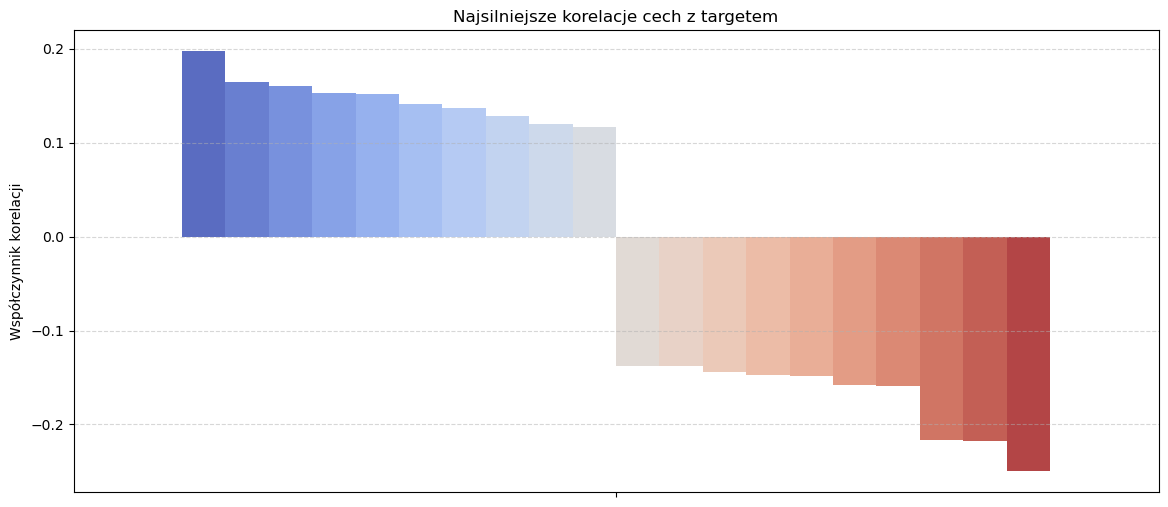

Top 10 cech najbardziej skorelowanych z targetem:
F27    0.249652
F25    0.218069
F29    0.216148
F0     0.197384
F69    0.164918
F68    0.159776
F26    0.158837
F28    0.157520
F70    0.153309
F55    0.151596
dtype: float64
reprezentacja biblioteczna


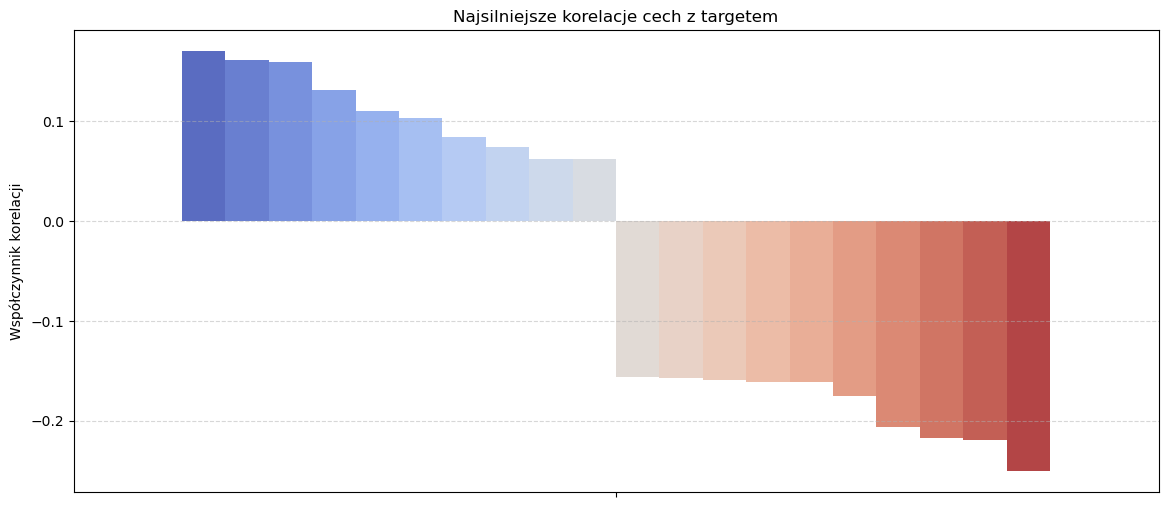

Top 10 cech najbardziej skorelowanych z targetem:
F3     0.250430
F1     0.218758
F5     0.216773
F73    0.205867
F6     0.175583
F79    0.170067
F66    0.161282
F7     0.160909
F2     0.160839
F78    0.159328
dtype: float64


In [62]:
print("ANALIZA KORELACJI CECH Z TARGETEM")
print('Nasza reprezentacja')
analyze_corr_with_target(X,y)
print("reprezentacja biblioteczna")
analyze_corr_with_target(X_librosa,y_librosa)

## Enkodowanie, podział danych i skalowanie

In [63]:
def encode_split_scale(X,y):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    print(f"Znalezione klasy: {le.classes_}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.fit_transform(X_test)

    print(f"Rozmiar zbioru treningowego: {X_train.shape}")
    print(f"Rozmiar zbioru testowego: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test, le

In [73]:
X_train , X_test, y_train, y_test, le = encode_split_scale(X,y)
X_train_librosa, X_test_librosa, y_train_librosa ,y_test_librosa, le_librosa = encode_split_scale(X_librosa,y_librosa)
#X_train_echonet , X_test_echonet, y_train_echonet,y_test_echonet , le_echonet = encode_split_scale(X_echonest,y_echonest)

Znalezione klasy: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Rozmiar zbioru treningowego: (6395, 123)
Rozmiar zbioru testowego: (1599, 123)
Znalezione klasy: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Rozmiar zbioru treningowego: (6397, 89)
Rozmiar zbioru testowego: (1600, 89)


## Optymalizacja hiperparametrow z wykorzystaniem optuny

In [76]:
import optuna
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

def train_with_optuna(X_train, y_train, X_test, y_test, model_class, param_func, n_trials=20):
    print(f"Optuna Optimization for {model_class.__name__}")
    print()
    
    base_default_kwargs = {}
        
    if model_class.__name__ == 'XGBClassifier':
        base_default_kwargs = {
            'use_label_encoder': False, 
            'eval_metric': 'mlogloss', 
            'random_state': 42, 
            'n_jobs': -1,
            'verbosity': 0
        }
    elif hasattr(model_class(), 'random_state'):
        base_default_kwargs['random_state'] = 42
        if 'n_jobs' in model_class().get_params():
            base_default_kwargs['n_jobs'] = -1
    else:
        if 'n_jobs' in model_class().get_params():
            base_default_kwargs['n_jobs'] = -1

    def objective(trial):
        params = param_func(trial)
        
        current_kwargs = base_default_kwargs.copy()
   
        current_kwargs.update(params)

        model = model_class(**current_kwargs)

        scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
        return scores.mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print()
    print(f"Najlepsze parametry: {study.best_params}")
    print(f"Najlepsza dokładność (CV mean): {study.best_value}")
    print()
    
    best_params = study.best_params
    

    final_kwargs = base_default_kwargs.copy()
    final_kwargs.update(best_params)

    best_model = model_class(**final_kwargs)
    best_model.fit(X_train, y_train)
    
    test_acc = accuracy_score(y_test, best_model.predict(X_test))
    print(f"Dokładność na zbiorze testowym: {test_acc:.4f}")
    
    return best_model, study.best_params, test_acc

In [77]:
def xgb_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'booster': trial.suggest_categorical('booster', ['gbtree']),
    }

xgb_model,best_params,best_acc = train_with_optuna(X_train,y_train,X_test,y_test,XGBClassifier,xgb_params,n_trials=20)

xgb_model_librosa,best_params_librosa,best_acc_librosa = train_with_optuna(X_train_librosa, y_train_librosa, X_test_librosa, y_test_librosa, XGBClassifier, xgb_params, n_trials=20)

#xgb_model_echonet,best_params_echonet,best_acc_echonet = train_with_optuna(X_train_echonet, y_train_echonet, X_test_echonet, y_test_echonet, XGBClassifier, xgb_params, n_trials=20)

Optuna Optimization for XGBClassifier



Best trial: 4. Best value: 0.54996: 100%|██████████| 20/20 [13:59<00:00, 41.97s/it]



Najlepsze parametry: {'n_estimators': 900, 'max_depth': 8, 'min_child_weight': 3, 'learning_rate': 0.023613462383716855, 'subsample': 0.6789406981933361, 'colsample_bytree': 0.8051695051554807, 'gamma': 3.925475543169192e-06, 'reg_alpha': 4.935612071976021e-07, 'reg_lambda': 0.021894094628556522, 'booster': 'gbtree'}
Najlepsza dokładność (CV mean): 0.5499595887739551

Dokładność na zbiorze testowym: 0.5672
Optuna Optimization for XGBClassifier



Best trial: 16. Best value: 0.556354: 100%|██████████| 20/20 [14:20<00:00, 43.01s/it]



Najlepsze parametry: {'n_estimators': 600, 'max_depth': 8, 'min_child_weight': 4, 'learning_rate': 0.03917274338321365, 'subsample': 0.7794594466231207, 'colsample_bytree': 0.8872171593773561, 'gamma': 8.501882133377952e-07, 'reg_alpha': 0.31328546763110526, 'reg_lambda': 0.0022907293264857274, 'booster': 'gbtree'}
Najlepsza dokładność (CV mean): 0.556354446212427

Dokładność na zbiorze testowym: 0.5637


PORÓWNANIE WYNIKÓW: WŁASNA REPREZENTACJA vs LIBROSA
MODEL / ZBIÓR DANYCH           | ACCURACY  
---------------------------------------------
Własna Reprezentacja           | 0.5672
Librosa                        | 0.5637
---------------------------------------------
Lepszy wynik: Własna Reprezentacja (różnica: 0.0035)




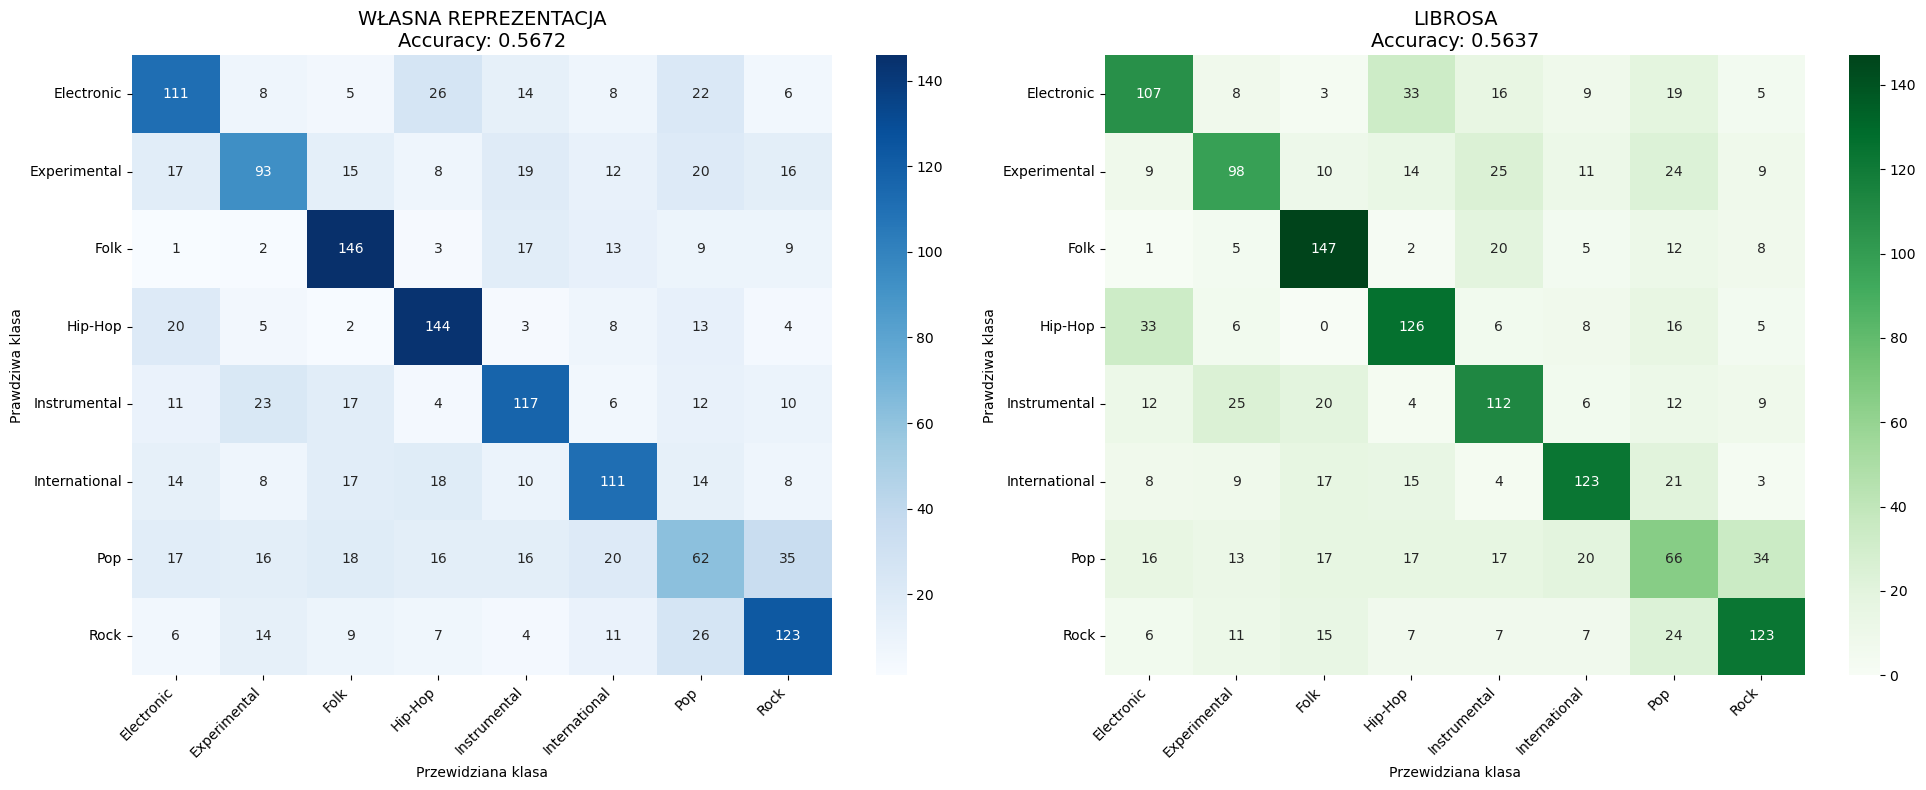


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - WŁASNA REPREZENTACJA
               precision    recall  f1-score   support

   Electronic       0.56      0.56      0.56       200
 Experimental       0.55      0.47      0.50       200
         Folk       0.64      0.73      0.68       200
      Hip-Hop       0.64      0.72      0.68       199
 Instrumental       0.58      0.58      0.58       200
International       0.59      0.56      0.57       200
          Pop       0.35      0.31      0.33       200
         Rock       0.58      0.61      0.60       200

     accuracy                           0.57      1599
    macro avg       0.56      0.57      0.56      1599
 weighted avg       0.56      0.57      0.56      1599


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - LIBROSA
               precision    recall  f1-score   support

   Electronic       0.56      0.54      0.55       200
 Experimental       0.56      0.49      0.52       200
         Folk       0.64      0.73      0.69       200
      Hip-Hop    

In [78]:

compare_models(xgb_model, X_test, y_test, 'Własna Reprezentacja', best_params,
               xgb_model_librosa, X_test_librosa, y_test_librosa, 'Librosa', best_params_librosa, 
               class_names=le.classes_)


In [79]:

def rf_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1200, step=50),
        'max_depth': trial.suggest_int('max_depth', 2,50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'criterion': trial.suggest_categorical('criterion',['gini','entropy','log_loss']),
    }
rf_model, best_params_rf, best_acc_rf = train_with_optuna(X_train, y_train, X_test, y_test, RandomForestClassifier, rf_params, n_trials=20)
rf_model_librosa, best_params_rf_librosa, best_acc_rf_librosa = train_with_optuna(X_train_librosa, y_train_librosa, X_test_librosa, y_test_librosa, RandomForestClassifier, rf_params, n_trials=20)

Optuna Optimization for RandomForestClassifier



Best trial: 11. Best value: 0.515872: 100%|██████████| 20/20 [01:58<00:00,  5.92s/it]



Najlepsze parametry: {'n_estimators': 1200, 'max_depth': 32, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini'}
Najlepsza dokładność (CV mean): 0.5158715310396075

Dokładność na zbiorze testowym: 0.5172
Optuna Optimization for RandomForestClassifier



Best trial: 15. Best value: 0.517588: 100%|██████████| 20/20 [01:13<00:00,  3.69s/it]



Najlepsze parametry: {'n_estimators': 950, 'max_depth': 21, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'gini'}
Najlepsza dokładność (CV mean): 0.5175876888596864

Dokładność na zbiorze testowym: 0.5188


PORÓWNANIE WYNIKÓW: WŁASNA REPREZENTACJA vs LIBROSA
MODEL / ZBIÓR DANYCH           | ACCURACY  
---------------------------------------------
Własna Reprezentacja           | 0.5172
Librosa                        | 0.5188
---------------------------------------------
Lepszy wynik: Librosa (różnica: 0.0016)




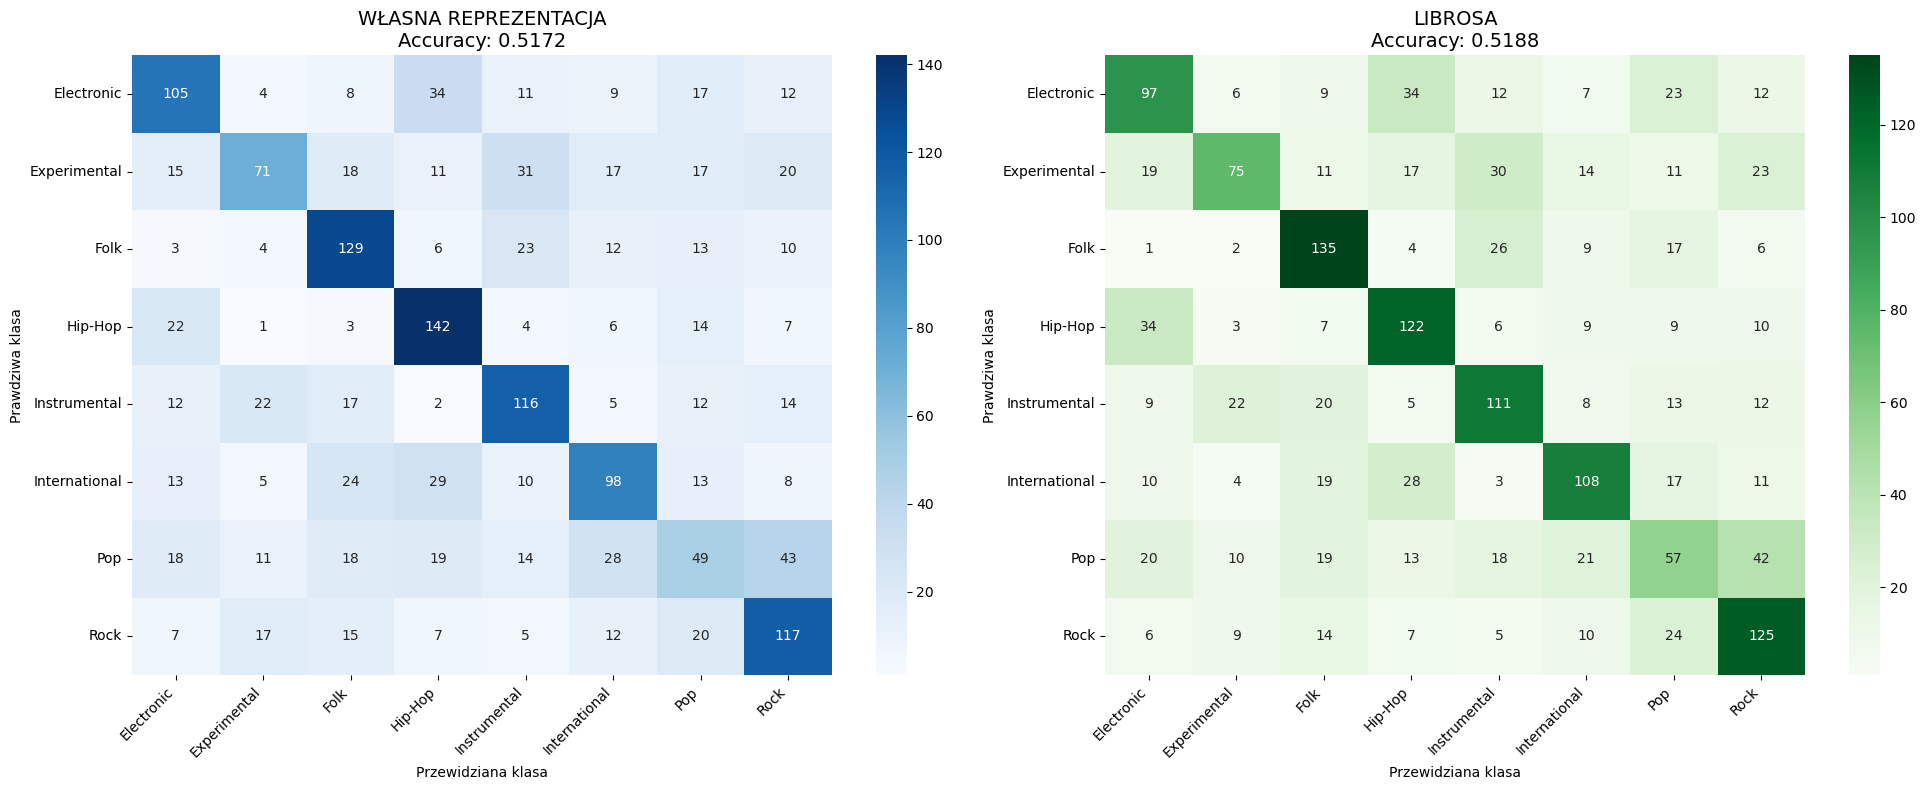


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - WŁASNA REPREZENTACJA
               precision    recall  f1-score   support

   Electronic       0.54      0.53      0.53       200
 Experimental       0.53      0.35      0.42       200
         Folk       0.56      0.65      0.60       200
      Hip-Hop       0.57      0.71      0.63       199
 Instrumental       0.54      0.58      0.56       200
International       0.52      0.49      0.51       200
          Pop       0.32      0.24      0.28       200
         Rock       0.51      0.58      0.54       200

     accuracy                           0.52      1599
    macro avg       0.51      0.52      0.51      1599
 weighted avg       0.51      0.52      0.51      1599


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - LIBROSA
               precision    recall  f1-score   support

   Electronic       0.49      0.48      0.49       200
 Experimental       0.57      0.38      0.45       200
         Folk       0.58      0.68      0.62       200
      Hip-Hop    

In [80]:
compare_models(rf_model, X_test, y_test, 'Własna Reprezentacja', best_params_rf,
               rf_model_librosa, X_test_librosa, y_test_librosa, 'Librosa', best_params_rf_librosa, 
               class_names=le.classes_)


In [81]:
def knn_params(trial):
    return {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 200),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
    }
knn_model, best_params_knn, best_acc_knn = train_with_optuna(X_train, y_train, X_test, y_test, KNeighborsClassifier, knn_params, n_trials=20)
knn_model_librosa, best_params_knn_librosa, best_acc_knn_librosa = train_with_optuna(X_train_librosa, y_train_librosa, X_test_librosa, y_test_librosa, KNeighborsClassifier, knn_params, n_trials=20)

Optuna Optimization for KNeighborsClassifier



Best trial: 3. Best value: 0.441595: 100%|██████████| 20/20 [00:02<00:00,  9.27it/s]



Najlepsze parametry: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'minkowski'}
Najlepsza dokładność (CV mean): 0.4415945530245469

Dokładność na zbiorze testowym: 0.4628
Optuna Optimization for KNeighborsClassifier



Best trial: 10. Best value: 0.481945: 100%|██████████| 20/20 [00:02<00:00,  8.61it/s]


Najlepsze parametry: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'manhattan'}
Najlepsza dokładność (CV mean): 0.48194451407891775

Dokładność na zbiorze testowym: 0.4906


PORÓWNANIE WYNIKÓW: WŁASNA REPREZENTACJA vs LIBROSA
MODEL / ZBIÓR DANYCH           | ACCURACY  
---------------------------------------------
Własna Reprezentacja           | 0.4628
Librosa                        | 0.4906
---------------------------------------------
Lepszy wynik: Librosa (różnica: 0.0278)




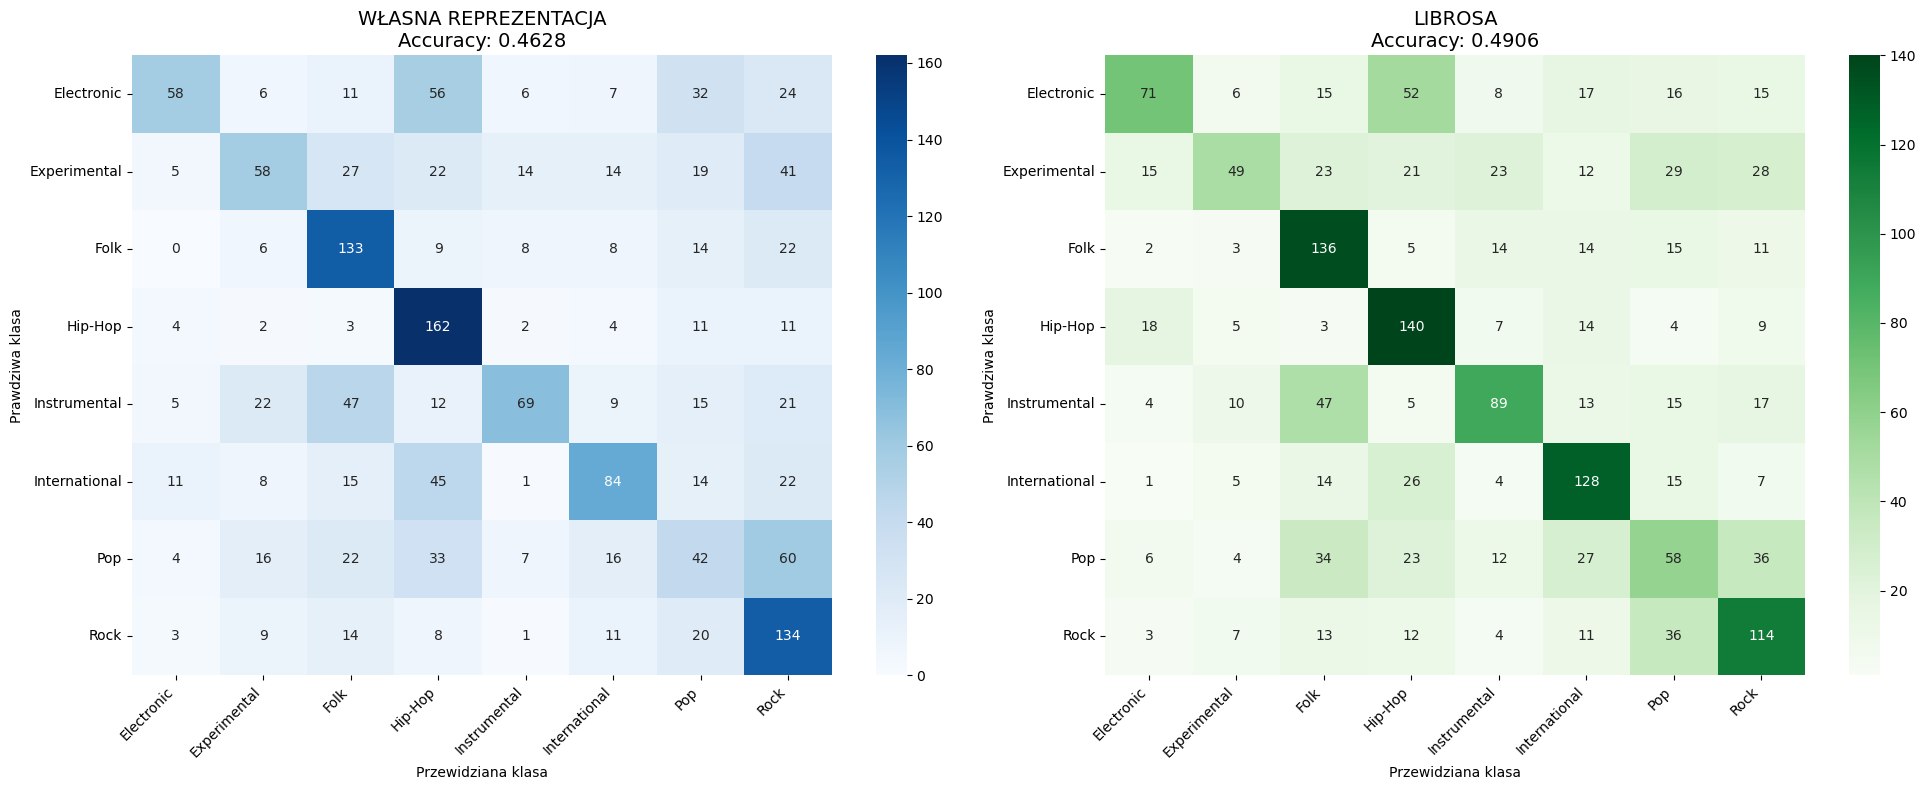


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - WŁASNA REPREZENTACJA
               precision    recall  f1-score   support

   Electronic       0.64      0.29      0.40       200
 Experimental       0.46      0.29      0.35       200
         Folk       0.49      0.67      0.56       200
      Hip-Hop       0.47      0.81      0.59       199
 Instrumental       0.64      0.34      0.45       200
International       0.55      0.42      0.48       200
          Pop       0.25      0.21      0.23       200
         Rock       0.40      0.67      0.50       200

     accuracy                           0.46      1599
    macro avg       0.49      0.46      0.45      1599
 weighted avg       0.49      0.46      0.45      1599


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - LIBROSA
               precision    recall  f1-score   support

   Electronic       0.59      0.35      0.44       200
 Experimental       0.55      0.24      0.34       200
         Folk       0.48      0.68      0.56       200
      Hip-Hop    

In [82]:
compare_models(knn_model, X_test, y_test, 'Własna Reprezentacja', best_params_knn,
               knn_model_librosa, X_test_librosa, y_test_librosa, 'Librosa', best_params_knn_librosa, 
               class_names=le.classes_)


In [83]:
def svm_params(trial):
    return {
        'C': trial.suggest_float('C', 0.1, 100.0, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly']),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])
    }
svm_model, best_params_svm, best_acc_svm = train_with_optuna(X_train, y_train, X_test, y_test, SVC, svm_params, n_trials=15)
svm_model_librosa, best_params_svm_librosa, best_acc_svm_librosa = train_with_optuna(X_train_librosa, y_train_librosa, X_test_librosa, y_test_librosa, SVC, svm_params, n_trials=15)

Optuna Optimization for SVC



Best trial: 14. Best value: 0.522439: 100%|██████████| 15/15 [01:19<00:00,  5.27s/it]



Najlepsze parametry: {'C': 6.190163441748896, 'kernel': 'rbf', 'gamma': 'scale'}
Najlepsza dokładność (CV mean): 0.5224392356907722

Dokładność na zbiorze testowym: 0.5403
Optuna Optimization for SVC



Best trial: 14. Best value: 0.536814: 100%|██████████| 15/15 [03:15<00:00, 13.00s/it]



Najlepsze parametry: {'C': 18.900472576815694, 'kernel': 'rbf', 'gamma': 'auto'}
Najlepsza dokładność (CV mean): 0.5368142800220602

Dokładność na zbiorze testowym: 0.5619


PORÓWNANIE WYNIKÓW: WŁASNA REPREZENTACJA vs LIBROSA
MODEL / ZBIÓR DANYCH           | ACCURACY  
---------------------------------------------
Własna Reprezentacja           | 0.5403
Librosa                        | 0.5619
---------------------------------------------
Lepszy wynik: Librosa (różnica: 0.0215)




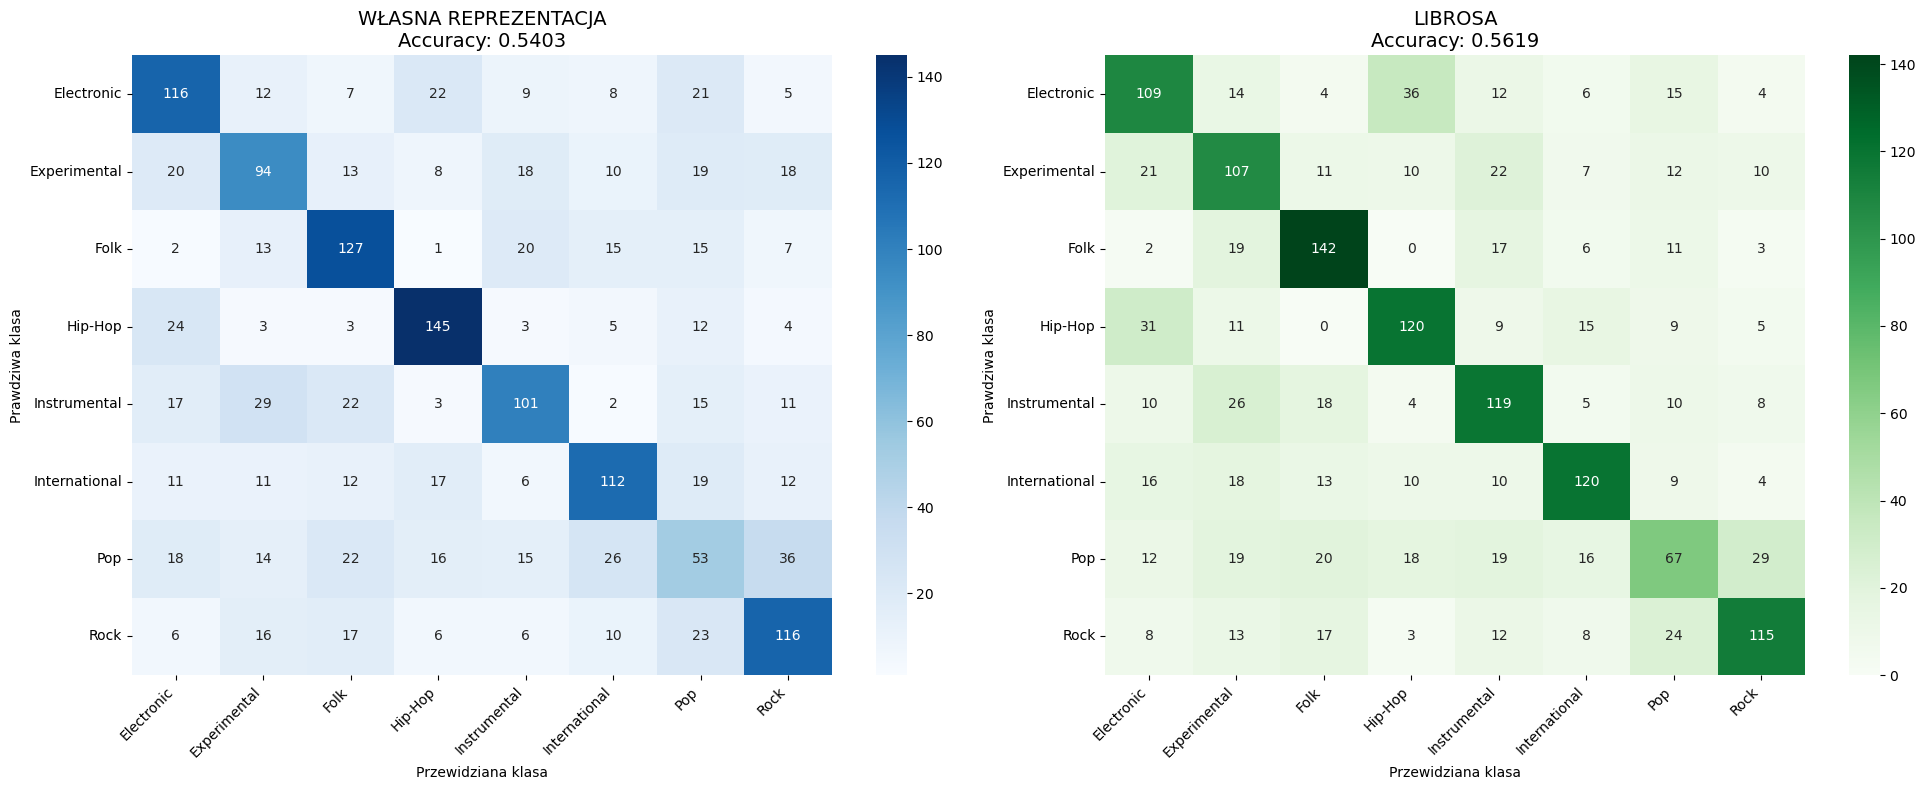


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - WŁASNA REPREZENTACJA
               precision    recall  f1-score   support

   Electronic       0.54      0.58      0.56       200
 Experimental       0.49      0.47      0.48       200
         Folk       0.57      0.64      0.60       200
      Hip-Hop       0.67      0.73      0.70       199
 Instrumental       0.57      0.51      0.53       200
International       0.60      0.56      0.58       200
          Pop       0.30      0.27      0.28       200
         Rock       0.56      0.58      0.57       200

     accuracy                           0.54      1599
    macro avg       0.54      0.54      0.54      1599
 weighted avg       0.54      0.54      0.54      1599


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - LIBROSA
               precision    recall  f1-score   support

   Electronic       0.52      0.55      0.53       200
 Experimental       0.47      0.54      0.50       200
         Folk       0.63      0.71      0.67       200
      Hip-Hop    

In [84]:
compare_models(svm_model, X_test, y_test, 'Własna Reprezentacja', best_params_svm,
               svm_model_librosa, X_test_librosa, y_test_librosa, 'Librosa', best_params_svm_librosa, 
               class_names=le.classes_)


In [85]:
def lr_params(trial):
    return {
        'C': trial.suggest_float('C', 0.01, 100.0, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'newton-cg', 'sag', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 500, 10000),
        #'penalty':trial.suggest_categorical('penalty',[None,'l1','l2','elasticnet'])
    }
lr_model, best_params_lr, best_acc_lr = train_with_optuna(X_train, y_train, X_test, y_test, LogisticRegression, lr_params, n_trials=30)
lr_model_librosa, best_params_lr_librosa, best_acc_lr_librosa = train_with_optuna(X_train_librosa, y_train_librosa, X_test_librosa, y_test_librosa, LogisticRegression, lr_params, n_trials=15)

Optuna Optimization for LogisticRegression



  0%|          | 0/30 [00:00<?, ?it/s]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.

/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.

/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.

Best trial: 0. Best value: 0.478186:   3%|▎         | 1/30 [00:00<00:19,  1.52it/s]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You


Najlepsze parametry: {'C': 0.2685121672531365, 'solver': 'lbfgs', 'max_iter': 3654}
Najlepsza dokładność (CV mean): 0.4792806625680233

Dokładność na zbiorze testowym: 0.4784
Optuna Optimization for LogisticRegression



  0%|          | 0/15 [00:00<?, ?it/s]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.

/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.

/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.

Best trial: 0. Best value: 0.486946:   7%|▋         | 1/15 [00:16<03:54, 16.75s/it]/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You


Najlepsze parametry: {'C': 0.05453762732748403, 'solver': 'newton-cg', 'max_iter': 6129}
Najlepsza dokładność (CV mean): 0.4935133655674975

Dokładność na zbiorze testowym: 0.4888



/opt/anaconda3/envs/audio_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.



PORÓWNANIE WYNIKÓW: WŁASNA REPREZENTACJA vs LIBROSA
MODEL / ZBIÓR DANYCH           | ACCURACY  
---------------------------------------------
Własna Reprezentacja           | 0.4784
Librosa                        | 0.4888
---------------------------------------------
Lepszy wynik: Librosa (różnica: 0.0103)




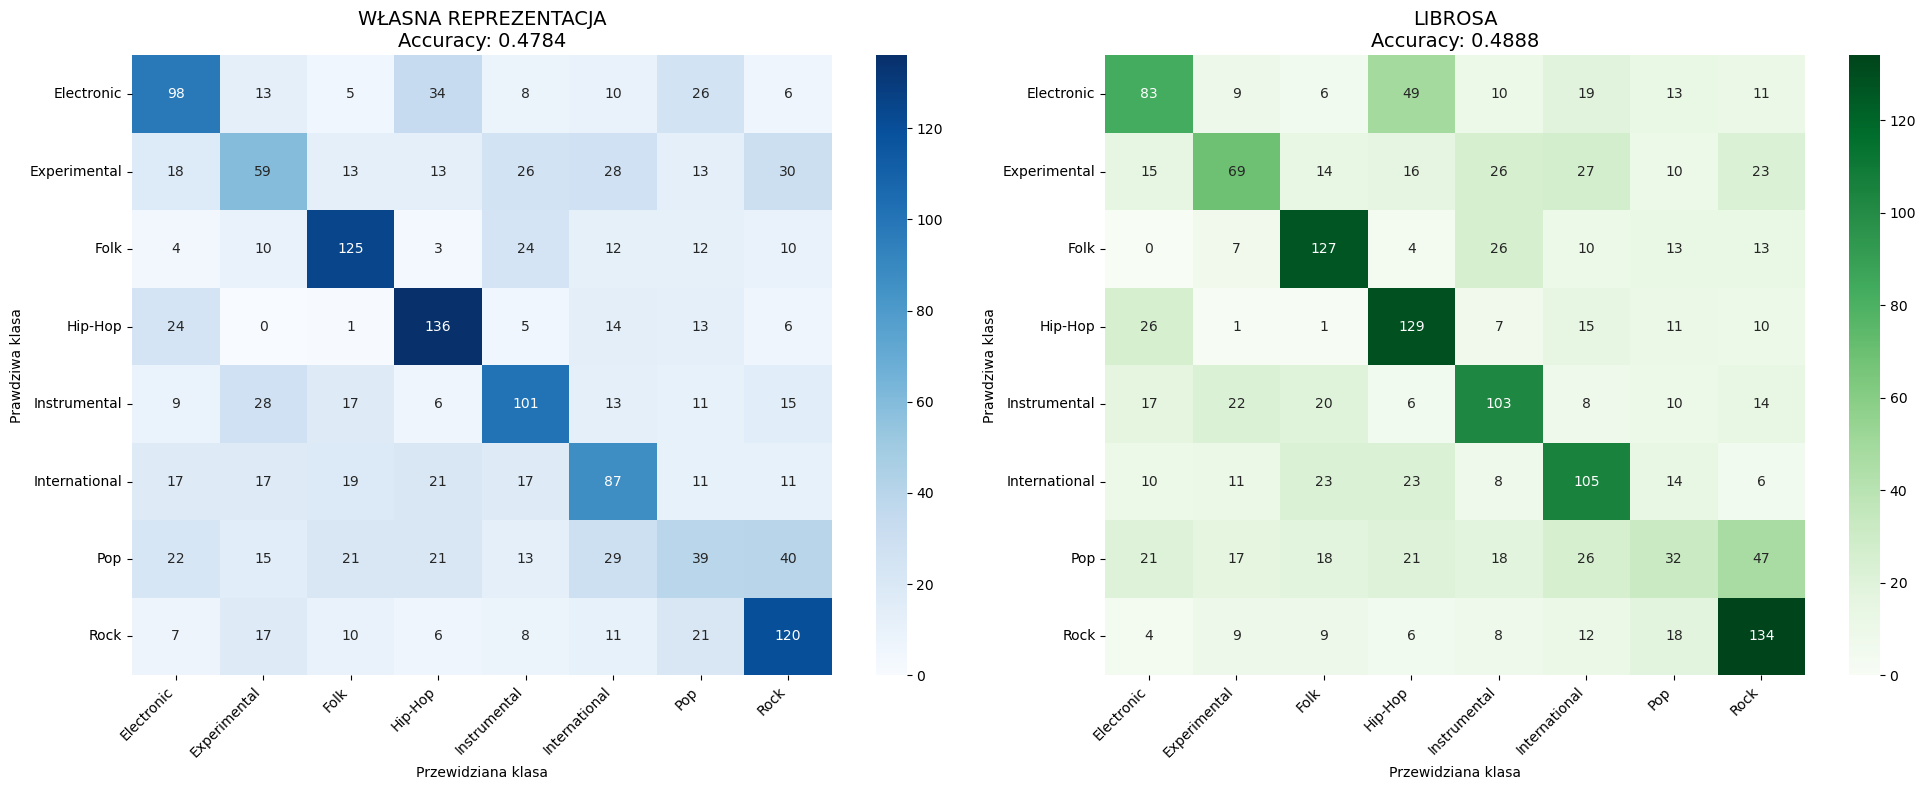


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - WŁASNA REPREZENTACJA
               precision    recall  f1-score   support

   Electronic       0.49      0.49      0.49       200
 Experimental       0.37      0.29      0.33       200
         Folk       0.59      0.62      0.61       200
      Hip-Hop       0.57      0.68      0.62       199
 Instrumental       0.50      0.51      0.50       200
International       0.43      0.43      0.43       200
          Pop       0.27      0.20      0.23       200
         Rock       0.50      0.60      0.55       200

     accuracy                           0.48      1599
    macro avg       0.47      0.48      0.47      1599
 weighted avg       0.46      0.48      0.47      1599


SZCZEGÓŁOWY RAPORT KLASYFIKACJI - LIBROSA
               precision    recall  f1-score   support

   Electronic       0.47      0.41      0.44       200
 Experimental       0.48      0.34      0.40       200
         Folk       0.58      0.64      0.61       200
      Hip-Hop    

In [86]:
compare_models(lr_model, X_test, y_test, 'Własna Reprezentacja', best_params_lr,
               lr_model_librosa, X_test_librosa, y_test_librosa, 'Librosa', best_params_lr_librosa, 
               class_names=le.classes_)


In [143]:
# from sklearn.metrics import accuracy_score
# import numpy as np
# from sklearn.decomposition import PCA

# # Trening XGBoost na wszystkich cechach, aby uzyskać ich ważność
# xgb_clf = XGBClassifier(n_estimators=200,learning_rate=0.2,max_depth=7,use_label_encoder=False, eval_metric='mlogloss', random_state=42)
# xgb_clf.fit(X_train, y_train)

# # Wyciągnięcie ważności cech
# importances = xgb_clf.feature_importances_
# indices = np.argsort(importances)[::-1]

# N = 60
# top_indices = indices[:N]
# print(f"Najważniejsze cechy (indeksy): {top_indices}")

# X_train_selected = X_train[:, top_indices]
# X_test_selected = X_test[:, top_indices]
# print(X_train.shape)
# pca = PCA(n_components=70, random_state=42)
# X_train_pca = pca.fit_transform(X_train)
# X_test_pca = pca.transform(X_test)


# xgb_clf_selected = XGBClassifier(n_estimators=600,learning_rate=0.25,use_label_encoder=False, eval_metric='mlogloss', random_state=42)
# xgb_clf_selected.fit(X_train_pca, y_train)
# y_pred = xgb_clf_selected.predict(X_test_pca)
# y_curious = xgb_clf_selected.predict(X_train_pca)

# print('Train accuracy:', accuracy_score(y_train, y_curious))
# print('Test accuracy:', accuracy_score(y_test, y_pred))

Najważniejsze cechy (indeksy): [  0  27  22  35  68  31  60  50  26  69   9  55 118  54  29   1  12  56
  10  28  71   7  20 119  33  52  30   8  41  39  59  57  97  17  99  70
  15   4  24  49  53  34 102  25  58  16 110   3  44   6  13  18  11  23
   2  92  47 104  75  63]
(6395, 123)
Train accuracy: 0.9998436278342455
Test accuracy: 0.5215759849906192


In [ ]:
# from sklearn.cluster import KMeans

# def train_kmeans(X, y_true):
#     print("\n" + "="*50)
#     print("K-MEANS (Poszukiwanie optymalnego K)")
#     print("="*50)
    
#     # Zakres K do sprawdzenia. Warto sprawdzić okolice rzeczywistej liczby gatunków.
#     true_k = len(np.unique(y_true))
#     print(f"Rzeczywista liczba gatunków (klastrów): {true_k}")
    
#     k_values = [true_k, true_k+2, true_k+5, 10, 20] # Przykładowe wartości
#     best_ari = -1
#     best_k = -1
#     best_model = None
    
#     print("Testowanie różnych wartości k...")
#     for k in k_values:
#         kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#         labels = kmeans.fit_predict(X)
        
#         sil = silhouette_score(X, labels)
#         ari = adjusted_rand_score(y_true, labels) # ARI mówi nam jak bardzo klastry pokrywają się z prawdziwymi klasami
        
#         print(f"  k={k} | Silhouette: {sil:.4f} | Adjusted Rand Index (zgodność z gatunkami): {ari:.4f}")
        
#         if ari > best_ari:
#             best_ari = ari
#             best_k = k
#             best_model = kmeans

#     print(f"\nNajlepsze k (wg ARI): {best_k}")
#     return best_model

# # Uruchomienie
# kmeans_model = train_kmeans(X_scaled, y_encoded)

In [135]:
# from sklearn.cluster import DBSCAN

# def train_dbscan(X, y_true):
#     print("\n" + "="*50)
#     print("DBSCAN (Grid Search po parametrach eps i min_samples)")
#     print("="*50)
    
#     # DBSCAN nie ma metody predict dla nowych danych w sklearn w sensie supervised.
#     # Używamy całego zbioru (lub próbki) do znalezienia struktury.
#     # Tutaj użyjemy X (cały dataset po skalowaniu), aby zobaczyć jak grupuje.
    
#     eps_values = [0.5, 1.0, 2.0, 3.0, 5.0]
#     min_samples_values = [3, 5, 10]
    
#     best_score = -1
#     best_params = {}
#     best_labels = None
    
#     print("Szukanie najlepszych parametrów (kryterium: Silhouette Score)...")
    
#     for eps in eps_values:
#         for min_samples in min_samples_values:
#             db = DBSCAN(eps=eps, min_samples=min_samples)
#             labels = db.fit_predict(X)
            
#             # Ignorujemy wynik, jeśli wszystkie punkty są szumem (-1) lub jest tylko 1 klaster (poza szumem)
#             unique_labels = set(labels)
#             if len(unique_labels) < 2 or (len(unique_labels) == 2 and -1 in unique_labels):
#                 continue
                
#             score = silhouette_score(X, labels)
#             ari = adjusted_rand_score(y_true, labels) # Porównanie z prawdziwymi gatunkami
            
#             if score > best_score:
#                 best_score = score
#                 best_params = {'eps': eps, 'min_samples': min_samples}
#                 best_labels = labels
#                 print(f"  New Best -> eps: {eps}, min_samples: {min_samples} | Silhouette: {score:.4f} | ARI: {ari:.4f}")
                
#     print(f"\nFinal Best Params: {best_params}")
#     print(f"Final Silhouette Score: {best_score:.4f}")
    
#     if best_labels is not None:
#         noise_ratio = np.sum(best_labels == -1) / len(best_labels)
#         print(f"Procent szumu: {noise_ratio:.2%}")
#         n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
#         print(f"Znaleziono klastrów: {n_clusters}")
        
#     return best_labels

# # Uruchomienie (na całym zbiorze X_scaled dla lepszego wglądu)
# dbscan_labels = train_dbscan(X_scaled, y_encoded)


DBSCAN (Grid Search po parametrach eps i min_samples)
Szukanie najlepszych parametrów (kryterium: Silhouette Score)...
  New Best -> eps: 3.0, min_samples: 3 | Silhouette: -0.1291 | ARI: 0.0000
  New Best -> eps: 3.0, min_samples: 3 | Silhouette: -0.1291 | ARI: 0.0000

Final Best Params: {'eps': 3.0, 'min_samples': 3}
Final Silhouette Score: -0.1291
Procent szumu: 99.89%
Znaleziono klastrów: 3

Final Best Params: {'eps': 3.0, 'min_samples': 3}
Final Silhouette Score: -0.1291
Procent szumu: 99.89%
Znaleziono klastrów: 3


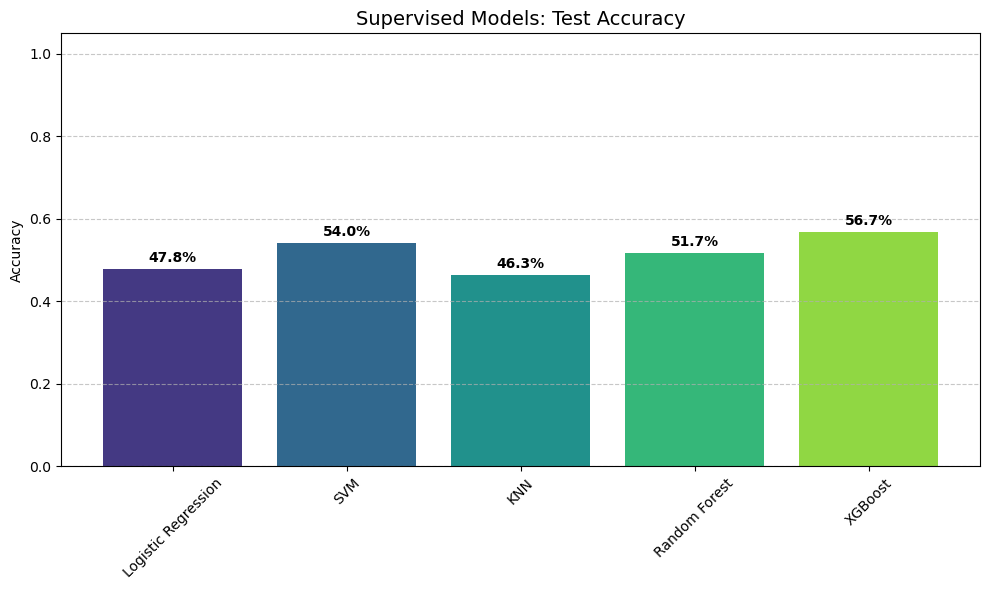

------------------------------------------------------------
MODEL                     | WYNIK     
------------------------------------------------------------
Logistic Regression |  0.47842401500938087 (Acc)
SVM |  0.5403377110694184 (Acc)
KNN |  0.4627892432770482 (Acc)
Random Forest |  0.517198248905566 (Acc)
XGBoost |  0.5672295184490307 (Acc)
------------------------------------------------------------


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

supervised_results = {}

if 'lr_model' in locals(): 
    supervised_results['Logistic Regression'] = accuracy_score(y_test, lr_model.predict(X_test))
if 'svm_model' in locals(): 
    supervised_results['SVM'] = accuracy_score(y_test, svm_model.predict(X_test))
if 'knn_model' in locals(): 
    supervised_results['KNN'] = accuracy_score(y_test, knn_model.predict(X_test))
if 'rf_model' in locals(): 
    supervised_results['Random Forest'] = accuracy_score(y_test, rf_model.predict(X_test))
if 'xgb_model' in locals() and xgb_model is not None: 
    supervised_results['XGBoost'] = accuracy_score(y_test, xgb_model.predict(X_test))


fig, ax = plt.subplots(figsize=(10, 6))


names = list(supervised_results.keys())
values = list(supervised_results.values())
colors = sns.color_palette("viridis", len(names))

bars = ax.bar(names, values, color=colors)
ax.set_title('Supervised Models: Test Accuracy', fontsize=14)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.tick_params(axis='x', rotation=45)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.tight_layout()
plt.show()

print("-" * 60)
print(f"{'MODEL':<25} | {'WYNIK':<10}")
print("-" * 60)
for params in list(supervised_results.items()):
    print(f"{params[0]} |  {params[1]} (Acc)")
print("-" * 60)